In [1]:
import glob
import os
import torch
import numpy as np
import cv2
import open3d as o3d
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from depth_anything_3.api import DepthAnything3
from sklearn.neighbors import KDTree

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
def setup_paths(data_folder="lab_four_picture"):
    """Create project paths for data, results, and models"""
    base_path = "/home/sasan/Desktop/project/depth_anything"
    paths = {
        'data': f"{base_path}/DATA/{data_folder}",
        'results': f"{base_path}/RESULTS/{data_folder}",
        'masks': f"{base_path}/RESULTS/{data_folder}/masks"
    }
    os.makedirs(paths['results'], exist_ok=True)
    os.makedirs(paths['masks'], exist_ok=True)

    return paths


def visualize_depth_and_confidence(images, depths, confidences, sample_idx=1):
    """Show RGB image, depth map, and confidence map side by side"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(images[sample_idx])
    axes[0].set_title('RGB Image')
    axes[0].axis('off')
    
    axes[1].imshow(depths[sample_idx], cmap='turbo')
    axes[1].set_title('Depth Map')
    axes[1].axis('off')
    
    axes[2].imshow(confidences[sample_idx], cmap='viridis')
    axes[2].set_title('Confidence Map')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_point_cloud_open3d(points, colors=None, window_name="Point Cloud"):
    """Display 3D point cloud with Open3D viewer"""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    
    if colors is not None:
        pcd.colors = o3d.utility.Vector3dVector(colors)
    
    o3d.visualization.draw_geometries([pcd], window_name=window_name)

# Florent's Note: These visualization functions are reusable across all steps
#setup paths
paths = setup_paths("lab_four_picture")
print("Project paths set up:", paths)



Project paths set up: {'data': '/home/sasan/Desktop/project/depth_anything/DATA/lab_picture', 'results': '/home/sasan/Desktop/project/depth_anything/RESULTS/lab_picture', 'masks': '/home/sasan/Desktop/project/depth_anything/RESULTS/lab_picture/masks'}


In [ ]:
# Initialize DepthAnything3 model

def load_da3_model(model_name="depth-anything/DA3NESTED-GIANT-LARGE-1.1"):
    """Initialize Depth-Anything-3 model on available device"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    model = DepthAnything3.from_pretrained(model_name)
    model = model.to(device=device)
    
    return model, device

# Time to test step 1: Load the DA3 model
model, device = load_da3_model()
print("DA3 model loaded successfully")

In [3]:
# Initialize DepthAnything3 model

def load_da3_model(model_name="depth-anything/DA3-GIANT-1.1"):
    """Initialize Depth-Anything-3 model on available device"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    model = DepthAnything3.from_pretrained(model_name)
    model = model.to(device=device)
    
    return model, device

# Time to test step 1: Load the DA3 model
model, device = load_da3_model()
print("DA3 model Giant loaded successfully")

Using device: cuda
[INFO ] using SwiGLU layer as FFN
DA3 model Giant loaded successfully


In [4]:
def load_images_from_folder(data_path, extensions=['*.jpg', '*.png', '*.jpeg']):
    """Scan folder and load all images with supported extensions"""
    image_files = []
    for ext in extensions:
        image_files.extend(sorted(glob.glob(os.path.join(data_path, ext))))
    
    print(f"Found {len(image_files)} images in {data_path}")
    return image_files

In [5]:

print(f"Project paths created: {paths}")
image_files = load_images_from_folder(paths['data'])

Project paths created: {'data': '/home/sasan/Desktop/project/depth_anything/DATA/lab_picture', 'results': '/home/sasan/Desktop/project/depth_anything/RESULTS/lab_picture', 'masks': '/home/sasan/Desktop/project/depth_anything/RESULTS/lab_picture/masks'}
Found 9 images in /home/sasan/Desktop/project/depth_anything/DATA/lab_picture


In [6]:
# %% Step 3: Run DA3 Inference for Depth and Poses
def run_da3_inference(model, image_files, process_res_method="upper_bound_resize"):
    """Run Depth-Anything-3 to get depth maps, camera poses, and intrinsics"""
    prediction = model.inference(
        image=image_files,
        infer_gs=True,
        process_res_method=process_res_method
    )
    
    print(f"Depth maps shape: {prediction.depth.shape}")
    print(f"Extrinsics shape: {prediction.extrinsics.shape}")
    print(f"Intrinsics shape: {prediction.intrinsics.shape}")
    print(f"Confidence shape: {prediction.conf.shape}")
    
    return prediction

[INFO ] Processed Images Done taking 0.26129937171936035 seconds. Shape:  torch.Size([9, 3, 504, 378])
[INFO ] Selecting reference view using strategy: saddle_balanced
[INFO ] Model Forward Pass Done. Time: 1.8148465156555176 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0051004886627197266 seconds
Depth maps shape: (9, 504, 378)
Extrinsics shape: (9, 3, 4)
Intrinsics shape: (9, 3, 3)
Confidence shape: (9, 504, 378)


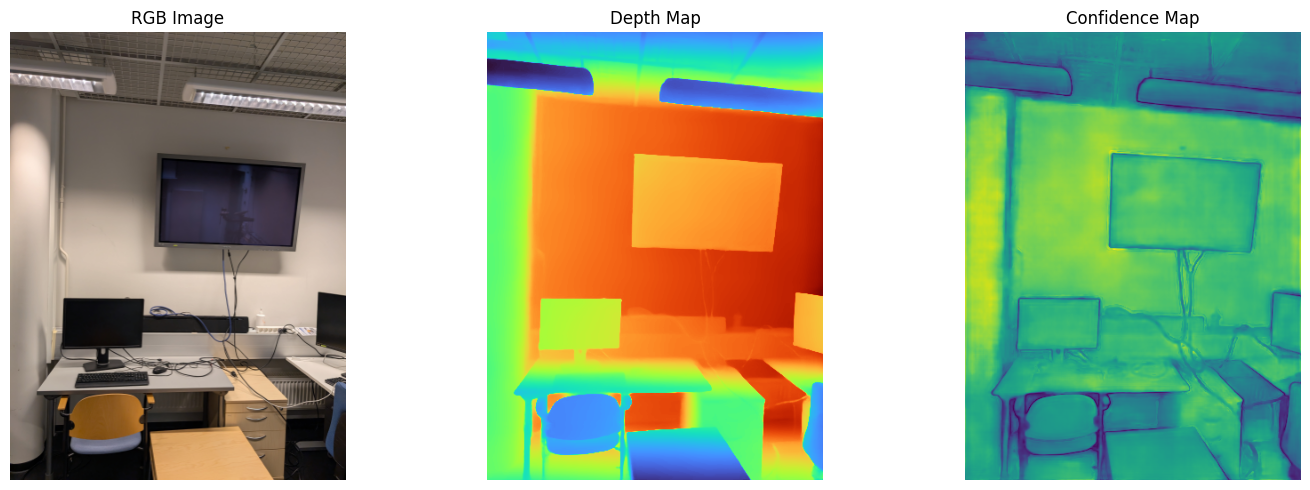

In [7]:
prediction = run_da3_inference(model, image_files)
visualize_depth_and_confidence(
    prediction.processed_images, 
    prediction.depth, 
    prediction.conf, 
    sample_idx=0
)

In [8]:
# %% Step 4: Generate 3D Point Cloud from Depth Maps
def depth_to_point_cloud(depth_map, rgb_image, intrinsics, extrinsics, conf_map=None, conf_thresh=0.5):
    """Back-project depth map to 3D points using camera parameters"""
    h, w = depth_map.shape
    fx, fy = intrinsics[0, 0], intrinsics[1, 1]
    cx, cy = intrinsics[0, 2], intrinsics[1, 2]
    
    # Create pixel grid
    u, v = np.meshgrid(np.arange(w), np.arange(h))
    
    # Filter by confidence if provided
    if conf_map is not None:
        valid_mask = conf_map > conf_thresh
        u, v, depth_map, rgb_image = u[valid_mask], v[valid_mask], depth_map[valid_mask], rgb_image[valid_mask]
    else:
        u, v, depth_map = u.flatten(), v.flatten(), depth_map.flatten()
        rgb_image = rgb_image.reshape(-1, 3)
    
    # Back-project to camera coordinates
    x = (u - cx) * depth_map / fx
    y = (v - cy) * depth_map / fy
    z = depth_map
    
    points_cam = np.stack([x, y, z], axis=-1)
    
    # Transform to world coordinates using extrinsics (w2c format)
    R = extrinsics[:3, :3]
    t = extrinsics[:3, 3]
    points_world = (points_cam - t) @ R  # Inverse transform
    
    colors = rgb_image.astype(np.float32) / 255.0
    
    return points_world, colors

In [9]:
def merge_point_clouds(prediction, conf_thresh=0.5):
    """Combine all frames into single point cloud"""
    all_points = []
    all_colors = []
    
    n_frames = len(prediction.depth)
    
    for i in range(n_frames):
        points, colors = depth_to_point_cloud(
            prediction.depth[i],
            prediction.processed_images[i],
            prediction.intrinsics[i],
            prediction.extrinsics[i],
            prediction.conf[i],
            conf_thresh
        )
        all_points.append(points)
        all_colors.append(colors)
    
    merged_points = np.vstack(all_points)
    merged_colors = np.vstack(all_colors)
    
    print(f"Merged point cloud: {len(merged_points)} points")
    return merged_points, merged_colors

In [10]:
# Time to Generate 3D point cloud
points_3d, colors_3d = merge_point_clouds(prediction, conf_thresh=0.4)
visualize_point_cloud_open3d(points_3d, colors_3d, window_name="Full Scene Point Cloud")

Merged point cloud: 1714608 points


In [11]:
# %% Step 4b: Cleaning the 3D Geometry [OPTIONAL]
import time

def clean_point_cloud_open3d(points_3d, colors_3d, nb_neighbors=20, std_ratio=2.0):
    """
    Cleans a point cloud using Statistical Outlier Removal (SOR) via Open3D.
    """
    try:
        import open3d as o3d
    except ImportError:
        raise ImportError("Open3D is not installed. Run `pip install open3d` or use the scipy version.")

    # 1. Convert Numpy to Open3D PointCloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_3d)
    
    # Open3D expects colors in float [0, 1]. If inputs are int [0, 255], normalize them.
    if colors_3d.max() > 1.0:
        pcd.colors = o3d.utility.Vector3dVector(colors_3d / 255.0)
    else:
        pcd.colors = o3d.utility.Vector3dVector(colors_3d)

    # 2. Run SOR (Implemented in optimized C++)
    # cl: The cleaned point cloud object
    # ind: The indices of the points that remain
    cl, ind = pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors,
                                             std_ratio=std_ratio)

    # 3. Use the indices to filter the original numpy arrays 
    # (This ensures we preserve exact original data types/values if needed)
    inlier_mask = np.asarray(ind)
    
    cleaned_points = points_3d[inlier_mask]
    cleaned_colors = colors_3d[inlier_mask]

    return cleaned_points, cleaned_colors

def clean_point_cloud_scipy(points_3d, colors_3d, nb_neighbors=20, std_ratio=2.0):
    """
    Cleans a point cloud using SOR via Scipy cKDTree.
    """
    from scipy.spatial import cKDTree

    # 1. Build KD-Tree
    tree = cKDTree(points_3d)

    # 2. Query neighbors
    # k needs to be nb_neighbors + 1 because the point itself is included in results
    distances, _ = tree.query(points_3d, k=nb_neighbors + 1, workers=-1) 
    
    # Exclude the first column (distance to self, which is 0)
    mean_distances = np.mean(distances[:, 1:], axis=1)

    # 3. Calculate statistics
    global_mean = np.mean(mean_distances)
    global_std = np.std(mean_distances)

    # 4. Generate Mask
    distance_threshold = global_mean + (std_ratio * global_std)
    mask = mean_distances < distance_threshold

    return points_3d[mask], colors_3d[mask]

# --- Demo Usage ---
if __name__ == "__main__":

    # Try Open3D method
    try:
        start = time.time()
        clean_pts, clean_cols = clean_point_cloud_open3d(points_3d, colors_3d)
        end = time.time()
        print(f"\n[Open3D] Cleaned shape: {clean_pts.shape}")
        print(f"[Open3D] Time taken: {end - start:.4f} seconds")
    except ImportError:
        print("\n[Open3D] Skipped (library not found)")

    # Try Scipy method
    start = time.time()
    clean_pts_sci, clean_cols_sci = clean_point_cloud_scipy(points_3d, colors_3d)
    end = time.time()
    print(f"\n[Scipy] Cleaned shape: {clean_pts_sci.shape}")
    print(f"[Scipy] Time taken: {end - start:.4f} seconds")


[Open3D] Cleaned shape: (1675245, 3)
[Open3D] Time taken: 1.6123 seconds

[Scipy] Cleaned shape: (1675186, 3)
[Scipy] Time taken: 0.6921 seconds


In [14]:
visualize_point_cloud_open3d(clean_pts_sci, clean_cols_sci, window_name="Full Scene Point Cloud")


In [ ]:
#export glb and gaussian splatting ply:

def export_da3_output(model, image_files, output_dir, conf_threshold_percentile=40.0):
    prediction = model.inference(
        image=image_files,
        infer_gs=True,
        process_res_method="upper_bound_resize",
        export_dir=output_dir,
        export_format = "glb-gs_ply",
        conf_thresh_percentile=conf_threshold_percentile,
        num_max_points=100000,
        show_cameras=True
    )
    print(f"Exported outputs to {output_dir}")

export_prediction = export_da3_output(model, image_files, paths['results'], conf_threshold_percentile=40.0)

    

In [ ]:
 #%% Interactive Masking Tool (Click-to-Paint + SAM)
class MultiClassMaskPainter:
    """Interactive tool for painting multi-class masks on images"""
    
    def __init__(self, image, num_classes=5):
        self.image = image.copy()
        self.mask = np.zeros(image.shape[:2], dtype=np.uint8)
        self.current_class = 1
        self.brush_size = 20
        self.drawing = False
        self.num_classes = num_classes
        
        # Color palette for classes (0=background)
        self.class_colors = [
            (0, 0, 0),       # 0: Background
            (255, 0, 0),     # 1: Red
            (0, 255, 0),     # 2: Green
            (0, 0, 255),     # 3: Blue
            (255, 255, 0),   # 4: Yellow
            (255, 0, 255),   # 5: Magenta
        ]
    
    def mouse_callback(self, event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            self.drawing = True
            self.paint_mask(x, y)
        elif event == cv2.EVENT_MOUSEMOVE and self.drawing:
            self.paint_mask(x, y)
        elif event == cv2.EVENT_LBUTTONUP:
            self.drawing = False
    
    def paint_mask(self, x, y):
        cv2.circle(self.mask, (x, y), self.brush_size, self.current_class, -1)
    
    def get_overlay(self):
        overlay = self.image.copy()
        for class_id in range(1, self.num_classes + 1):
            mask_class = (self.mask == class_id)
            overlay[mask_class] = (0.6 * self.image[mask_class] + 
                                   0.4 * np.array(self.class_colors[class_id]))
        return overlay.astype(np.uint8)
    
    def run(self, window_name="Mask Painter"):
        cv2.namedWindow(window_name)
        cv2.setMouseCallback(window_name, self.mouse_callback)
        
        print("=== Mask Painting Tool ===")
        print("Keys: 1-5 = Select class | +/- = Brush size | 's' = Save | 'q' = Quit")
        
        while True:
            overlay = self.get_overlay()
            
            # Add UI info
            info_text = f"Class: {self.current_class} | Brush: {self.brush_size}"
            cv2.putText(overlay, info_text, (10, 30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
            
            cv2.imshow(window_name, overlay)
            
            key = cv2.waitKey(1) & 0xFF
            
            if key == ord('q'):
                break
            elif key == ord('s'):
                cv2.destroyAllWindows()
                return self.mask
            elif key in [ord('1'), ord('2'), ord('3'), ord('4'), ord('5')]:
                self.current_class = int(chr(key))
            elif key == ord('+') or key == ord('='):
                self.brush_size = min(50, self.brush_size + 5)
            elif key == ord('-') or key == ord('_'):
                self.brush_size = max(5, self.brush_size - 5)
        
        cv2.destroyAllWindows()
        return self.mask

def paint_mask_on_image(image, num_classes=5):
    """Launch interactive painting tool for single image"""
    painter = MultiClassMaskPainter(image, num_classes)
    mask = painter.run()
    return mask

def sam_segment_image(image, use_sam=False):
    """Apply SAM (Segment Anything) for automatic segmentation"""
    if not use_sam:
        print("SAM segmentation disabled, use manual painting instead")
        return None
    
    # Florent's Note: Add SAM integration here if needed
    # from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
    # This requires SAM checkpoint download and initialization
    
    print("SAM segmentation not yet implemented")
    return None

# Paint a mask on the first image
sample_image = prediction.processed_images[0]
sample_mask = paint_mask_on_image(sample_image, num_classes=5)
print(f"Mask created with {len(np.unique(sample_mask))} classes")

In [ ]:
# %% Apply Masks to 3D Point Cloud
def project_mask_to_3d(mask, depth_map, intrinsics, extrinsics, conf_map=None, conf_thresh=0.5):
    """Project 2D mask to 3D points using camera geometry"""
    h, w = depth_map.shape
    fx, fy = intrinsics[0, 0], intrinsics[1, 1]
    cx, cy = intrinsics[0, 2], intrinsics[1, 2]
    
    u, v = np.meshgrid(np.arange(w), np.arange(h))
    
    # Filter by confidence
    if conf_map is not None:
        valid_mask = conf_map > conf_thresh
        u, v, depth_map, mask = u[valid_mask], v[valid_mask], depth_map[valid_mask], mask[valid_mask]
    else:
        u, v, depth_map, mask = u.flatten(), v.flatten(), depth_map.flatten(), mask.flatten()
    
    # Back-project to camera coordinates
    x = (u - cx) * depth_map / fx
    y = (v - cy) * depth_map / fy
    z = depth_map
    
    points_cam = np.stack([x, y, z], axis=-1)
    
    # Transform to world coordinates
    R = extrinsics[:3, :3]
    t = extrinsics[:3, 3]
    points_world = (points_cam - t) @ R
    
    return points_world, mask

def filter_point_cloud_by_mask(points_3d, colors_3d, mask_labels, target_classes=None):
    """Keep only points belonging to specified mask classes"""
    if target_classes is None:
        target_classes = [1, 2, 3, 4, 5]  # All non-background
    
    valid_mask = np.isin(mask_labels, target_classes)
    filtered_points = points_3d[valid_mask]DA3-GIANT
    filtered_colors = colors_3d[valid_mask]
    filtered_labels = mask_labels[valid_mask]
    
    print(f"Filtered to {len(filtered_points)} points from classes {target_classes}")
    return filtered_points, filtered_colors, filtered_labels

def visualize_masked_point_cloud(points, colors, labels, num_classes=5):
    """Show point cloud with different colors per mask class"""
    # Create class-based color map
    class_colormap = np.array([
        [0.5, 0.5, 0.5],  # 0: Gray (background)
        [1.0, 0.0, 0.0],  # 1: Red
        [0.0, 1.0, 0.0],  # 2: Green
        [0.0, 0.0, 1.0],  # 3: Blue
        [1.0, 1.0, 0.0],  # 4: Yellow
        [1.0, 0.0, 1.0],  # 5: Magenta
    ])
    
    # Assign colors based on labels
    label_colors = class_colormap[labels]
    
    visualize_point_cloud_open3d(points, label_colors, window_name="Masked Point Cloud")

def visualize_masked_with_context(masked_points, masked_labels, full_points, full_colors, num_classes=5):
    """Show masked points (colored by class) together with all other points (dimmed)"""
    class_colormap = np.array([
        [0.5, 0.5, 0.5],  # 0: Gray (background)
        [1.0, 0.0, 0.0],  # 1: Red
        [0.0, 1.0, 0.0],  # 2: Green
        [0.0, 0.0, 1.0],  # 3: Blue
        [1.0, 1.0, 0.0],  # 4: Yellow
        [1.0, 0.0, 1.0],  # 5: Magenta
    ])
    
    # Create combined point cloud
    pcd_masked = o3d.geometry.PointCloud()
    pcd_masked.points = o3d.utility.Vector3dVector(masked_points)
    pcd_masked.colors = o3d.utility.Vector3dVector(class_colormap[masked_labels])
    
    # Dim the full scene points (multiply by 0.3 for darker appearance)
    pcd_full = o3d.geometry.PointCloud()
    pcd_full.points = o3d.utility.Vector3dVector(full_points)
    pcd_full.colors = o3d.utility.Vector3dVector(full_colors * 0.3)
    
    o3d.visualization.draw_geometries([pcd_masked, pcd_full], 
                                     window_name="Masked Points with Context")

In [ ]:
# Project mask to 3D
masked_points_3d, mask_labels_3d = project_mask_to_3d(
    sample_mask,
    prediction.depth[0],
    prediction.intrinsics[0],
    prediction.extrinsics[0],
    prediction.conf[0],
    conf_thresh=0.4
)

filtered_points, filtered_colors, filtered_labels = filter_point_cloud_by_mask(
    masked_points_3d, 
    colors_3d[:len(masked_points_3d)],  # Match size
    mask_labels_3d,
    target_classes=[1, 2, 3]  # Only keep these classes
)  

# Visualize masked points only
visualize_masked_point_cloud(filtered_points, filtered_colors, filtered_labels)

# Visualize masked points with full scene context
visualize_masked_with_context(filtered_points, filtered_labels, points_3d, colors_3d)